In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
from tqdm import tqdm
import pandas as pd
from zapbench import constants
from zapbench.ts_forecasting import data_source
import grain.python as grain
from zapbench import data_utils
from zapbench.models.child775_model import Model
import matplotlib.pyplot as plt


2025-09-22 13:52:32.684097: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/mnt/localdata/vijay/miniconda3/envs/zap/lib/python3.13/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
num_timesteps_context = 16

In [3]:
sources = []

# Iterate over all training conditions (excludes 'taxis'), and create
# data sources.
for condition_id in constants.CONDITIONS_TRAIN:
  config = data_source.TensorStoreTimeSeriesConfig(
      input_spec=data_utils.adjust_spec_for_condition_and_split(
          condition=condition_id,
          split='train',
          spec=data_utils.get_spec('240930_traces'),
          num_timesteps_context=num_timesteps_context),
      timesteps_input=num_timesteps_context,
      timesteps_output=constants.PREDICTION_WINDOW_LENGTH,
  )
  sources.append(data_source.TensorStoreTimeSeries(config, prefetch=True))

# Concatenate into a single source.
source = data_source.ConcatenatedTensorStoreTimeSeries(*sources)

f'{len(source)=}'

E0922 13:52:35.872922 1037958 google_auth_provider.cc:188] Could not find the credentials file in the standard gcloud location [/home/kumarv4@hhmi.org/.config/gcloud/application_default_credentials.json]. You may specify a credentials file using $GOOGLE_APPLICATION_CREDENTIALS, or to use Google application default credentials, run: gcloud auth application-default login


'len(source)=4676'

In [4]:

# Dynamically infer the necessary constants from the data source for model instantiation.

num_epochs = 1
shuffle=False
batch_size = 32

NUM_NEURONS_INFERRED = source[0]['series_input'].shape[1]
PREDICTION_WINDOW_LENGTH_INFERRED = constants.PREDICTION_WINDOW_LENGTH
NUM_TIMESTEPS_CONTEXT_INFERRED = num_timesteps_context
# Define the number of epochs to train for model.fit
epochs_to_train_for_model_fit = 120
# Setup train data loader: ensure num_epochs is 1 for consistent tf.data.Dataset generation per epoch
index_sampler = grain.IndexSampler(
    num_records=len(source),
    num_epochs=num_epochs, # This should be 1 as defined globally initially
    shard_options=grain.ShardOptions(
        shard_index=0, shard_count=1, drop_remainder=True),
    shuffle=shuffle,
    seed=101
)
data_loader = grain.DataLoader(
    data_source=source,
    sampler=index_sampler,
    operations=[
        grain.Batch(
            batch_size=batch_size, drop_remainder=True)
    ],
    worker_count=0
)
# Setup validation data loader: ensure num_epochs is 1
val_sources = []
for condition_id in constants.CONDITIONS_TRAIN: # Use training conditions for validation split
  config_val = data_source.TensorStoreTimeSeriesConfig(
      input_spec=data_utils.adjust_spec_for_condition_and_split(
          condition=condition_id,
          split='val', # Crucially, use 'val' split here
          spec=data_utils.get_spec('240930_traces'),
          num_timesteps_context=num_timesteps_context),
      timesteps_input=num_timesteps_context,
      timesteps_output=constants.PREDICTION_WINDOW_LENGTH,
  )
  val_sources.append(data_source.TensorStoreTimeSeries(config_val, prefetch=True))
val_source = data_source.ConcatenatedTensorStoreTimeSeries(*val_sources)
val_batch_size = batch_size # Use same batch size for validation
val_index_sampler = grain.IndexSampler(
    num_records=len(val_source),
    num_epochs=num_epochs, # This should be 1
    shard_options=grain.ShardOptions(
        shard_index=0, shard_count=1, drop_remainder=True),
    shuffle=False, # No need to shuffle validation data
    seed=101 # Consistent seed
)
val_data_loader = grain.DataLoader(
    data_source=val_source,
    sampler=val_index_sampler,
    operations=[
        grain.Batch(
            batch_size=val_batch_size, drop_remainder=True)
    ],
    worker_count=0
)
print(f'\nValidation data loader created with {len(val_source)} records and batch size {val_batch_size}.')



Validation data loader created with 469 records and batch size 32.


In [5]:
# mirrored_strategy = tf.distribute.MirroredStrategy()
# with mirrored_strategy.scope():
# Instantiate the model by passing the required constants.
model = Model(
    num_timesteps_context=NUM_TIMESTEPS_CONTEXT_INFERRED,
    num_neurons=NUM_NEURONS_INFERRED,
    prediction_window_length=PREDICTION_WINDOW_LENGTH_INFERRED
)
# Perform a dummy forward pass using the actual batch_size to build the model
# and ensure all layer shapes are determined, including those within FeatureExtractor.
dummy_input_for_build = tf.zeros((batch_size, NUM_TIMESTEPS_CONTEXT_INFERRED, NUM_NEURONS_INFERRED), dtype=tf.float32)
_ = model(dummy_input_for_build) # Call the model once to build its layers
print("\nShared-Weight MLP Model Summary (with encapsulated and consolidated FeatureExtractor and Residual Blocks):")
model.summary()
total_params = model.count_params()
# The input dimension to the MLP is now determined by the FeatureExtractor's output
# It's (conv1d_filters + 8 stats + (C-1) deltas + GLOBAL_STATE_DIM + EMBEDDING_DIM)
total_mlp_input_dim = (model.feature_extractor.conv1d_context_processor.filters +
                      8 + # number of static features (mean, std, min, max, last, first, median, range)
                      (model.NUM_TIMESTEPS_CONTEXT - 1) + # number of delta features
                      model.feature_extractor.GLOBAL_STATE_DIM +
                      model.feature_extractor.EMBEDDING_DIM)
print(f"\nTotal combined model parameters: {total_params:,}.")
print(f"This compact model shares its weights across {model.NUM_NEURONS} neurons to predict their future activity.")
print(f"This design is critical for managing the vast number of outputs ({model.NUM_NEURONS} neurons * {model.PREDICTION_WINDOW_LENGTH} steps), providing both local and global context, neuron identity, and now rate of change, with a total input dimension to the MLP of {total_mlp_input_dim}.")
# Now using the encapsulated 'fit' method with validation data.
model.fit(train_data_loader=data_loader, val_data_loader=val_data_loader, epochs=epochs_to_train_for_model_fit)

I0000 00:00:1758563573.838761 1037812 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46592 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:03:00.0, compute capability: 8.6
I0000 00:00:1758563573.839458 1037812 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 46857 MB memory:  -> device: 1, name: NVIDIA RTX A6000, pci bus id: 0000:04:00.0, compute capability: 8.6



Shared-Weight MLP Model Summary (with encapsulated and consolidated FeatureExtractor and Residual Blocks):


Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feature_extractor_layer         │ ?                      │    13,771,616 │
│ (FeatureExtractor)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ initial_bn (BatchNormalization) │ (2295072, 279)         │         1,116 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ initial_projection_dense        │ (2295072, 256)         │        71,680 │
│ (Dense)                         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block1 (ResidualBlock)      │ ?                      │        66,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block2 (ResidualBlock)      │ ?                      │        66,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block3 (ResidualBlock)      │ ?                      │        66,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block4 (ResidualBlock)      │ ?                      │        66,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_output_dense (Dense)      │ (2295072, 32)          │         8,224 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,119,900 (53.86 MB)

...

146/146 ━━━━━━━━━━━━━━━━━━━━ 104s 705ms/step - loss: 0.0310 - val_loss: 0.0307
Epoch 11/120


2025-09-22 14:11:17.473043: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 5288292435623491769
2025-09-22 14:11:17.473117: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 12807026318410606943


146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - loss: 0.0315

2025-09-22 14:12:53.790806: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 5288292435623491769
2025-09-22 14:12:53.790875: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 12807026318410606943


KeyboardInterrupt: 

In [7]:
model.summary()

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feature_extractor_layer         │ ?                      │    13,771,616 │
│ (FeatureExtractor)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ initial_bn (BatchNormalization) │ (2295072, 279)         │         1,116 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ initial_projection_dense        │ (2295072, 256)         │        71,680 │
│ (Dense)                         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block1 (ResidualBlock)      │ ?                      │        66,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block2 (ResidualBlock)      │ ?                      │        66,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block3 (ResidualBlock)      │ ?                      │        66,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block4 (ResidualBlock)      │ ?                      │        66,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_output_dense (Dense)      │ (2295072, 32)          │         8,224 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,354,490 (161.57 MB)

 Trainable params: 14,117,294 (53.85 MB)

 Non-trainable params: 2,606 (10.18 KB)

 Optimizer params: 28,234,590 (107.71 MB)

In [10]:
model.save("child775.keras", overwrite=False, zipped=True)

In [12]:
len(source)

4676

data_ix=4311;ix=62774


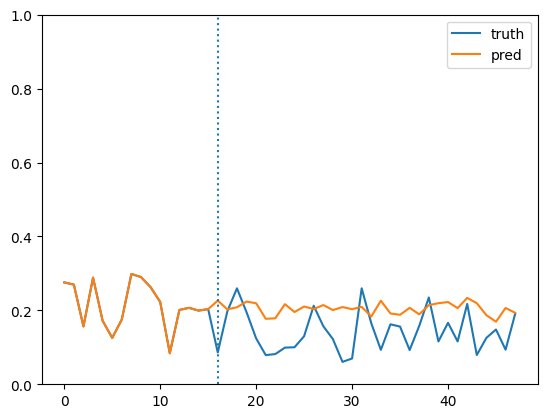

In [130]:
data_ix =  np.random.randint(len(source))
x = source[data_ix]['series_input']
y = source[data_ix]['series_output']

ypred = model.predict_non_batched(x)
ix = np.random.randint(x.shape[1])
print(f"{data_ix=};{ix=}")
plt.plot(np.concatenate([x[:, ix], y[:, ix]], axis=0), label="truth")
plt.plot(np.concatenate([x[:, ix], ypred[:, ix]], axis=0), label="pred")
plt.legend()
plt.ylim(0, 1.0)
plt.axvline(16, ls="dotted")

In [99]:
np.unravel_index(np.argmax(x), x.shape)

(np.int64(4), np.int64(66402))

In [116]:
import matplotlib as mpl

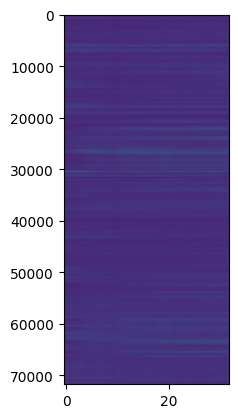

In [125]:
data_ix =  np.random.randint(len(source))
x = source[data_ix]['series_input']
y = source[data_ix]['series_output']

ix = np.random.randint(x.shape[1])

plt.imshow(y.T, aspect=1e-3)